## 📘 Most Important Techniques for Regression

🔹 **1. Correlation Analysis (Pearson)**  

🔹 **2. Skewness**  

🔹 **3. P-Value (from Linear Regression Summary)**  

🔹 **4. Variance Inflation Factor (VIF)**  

🔹 **5. Outlier Detection**  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
file = pd.read_csv('/content/drive/MyDrive/task/Predicting Car Prices based on Features/CarPrice_Assignment.csv')
file = file.drop("car_ID", axis =1)
file.head(1)

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0


In [3]:
file.shape

(205, 25)

In [4]:
file.head(3)

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0


In [5]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   CarName           205 non-null    object 
 2   fueltype          205 non-null    object 
 3   aspiration        205 non-null    object 
 4   doornumber        205 non-null    object 
 5   carbody           205 non-null    object 
 6   drivewheel        205 non-null    object 
 7   enginelocation    205 non-null    object 
 8   wheelbase         205 non-null    float64
 9   carlength         205 non-null    float64
 10  carwidth          205 non-null    float64
 11  carheight         205 non-null    float64
 12  curbweight        205 non-null    int64  
 13  enginetype        205 non-null    object 
 14  cylindernumber    205 non-null    object 
 15  enginesize        205 non-null    int64  
 16  fuelsystem        205 non-null    object 
 1

In [6]:
file.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## Null Value

In [7]:
file.isnull().sum()

,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0
carlength,0


## Finding duplicates

In [10]:
file.duplicated().sum()

np.int64(0)

In [11]:
file.columns

Index(['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [12]:
file["symboling"].value_counts()

,count
symboling,
0,67
1,54
2,32
3,27
-1,22
-2,3


In [13]:
file["fueltype"].value_counts()

,count
fueltype,
gas,185
diesel,20


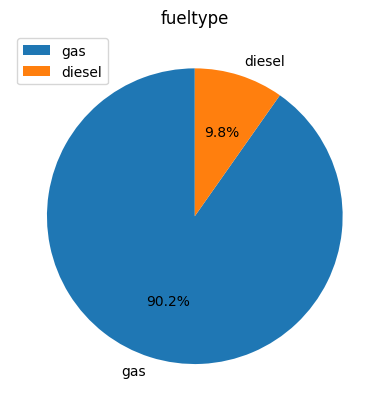

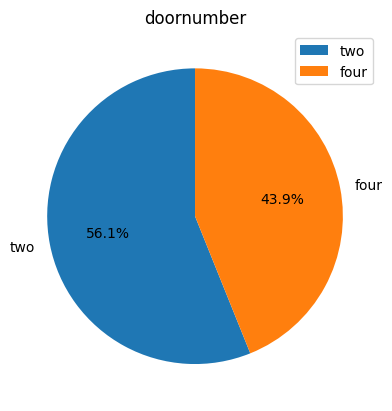

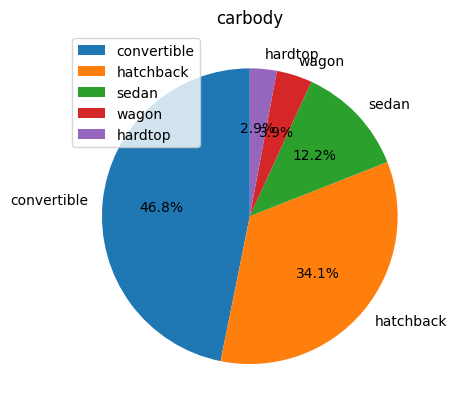

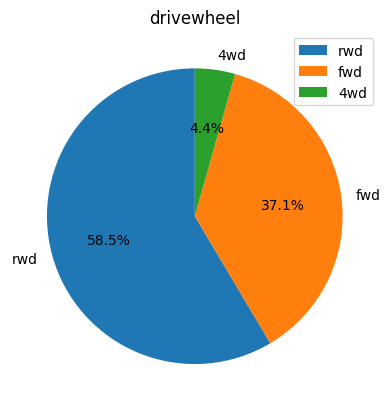

In [15]:
plt.pie(file["fueltype"].value_counts(), labels = file["fueltype"].unique() ,autopct='%1.1f%%', startangle=90)
plt.title("fueltype")
plt.legend()
plt.show()

plt.pie(file["doornumber"].value_counts(), labels = file["doornumber"].unique() ,autopct='%1.1f%%', startangle=90)
plt.title("doornumber")
plt.legend()
plt.show()

plt.pie(file["carbody"].value_counts(), labels = file["carbody"].unique() ,autopct='%1.1f%%', startangle=90)
plt.title("carbody")
plt.legend()
plt.show()

plt.pie(file["drivewheel"].value_counts(), labels = file["drivewheel"].unique() ,autopct='%1.1f%%', startangle=90)
plt.title("drivewheel")
plt.legend()
plt.show()

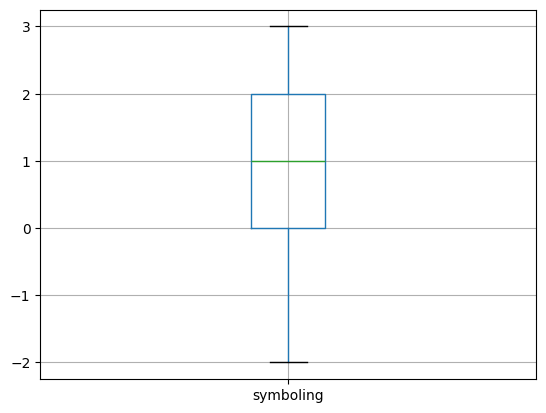

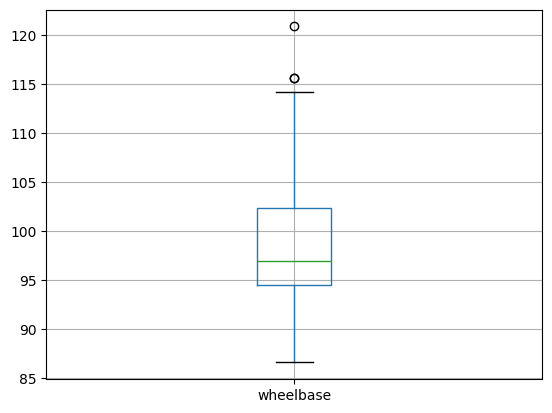

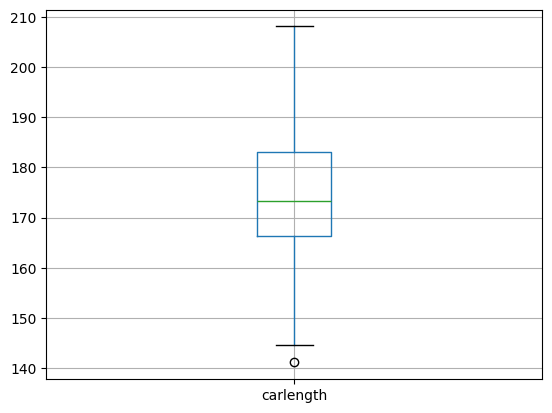

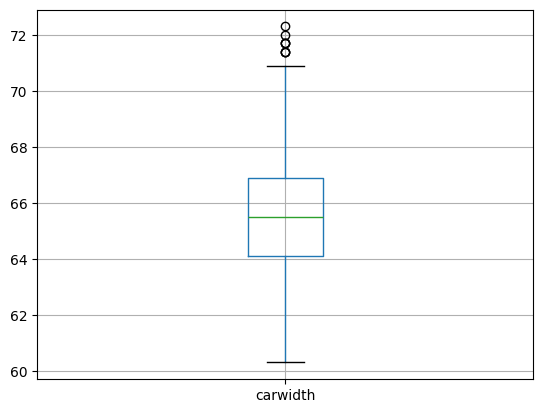

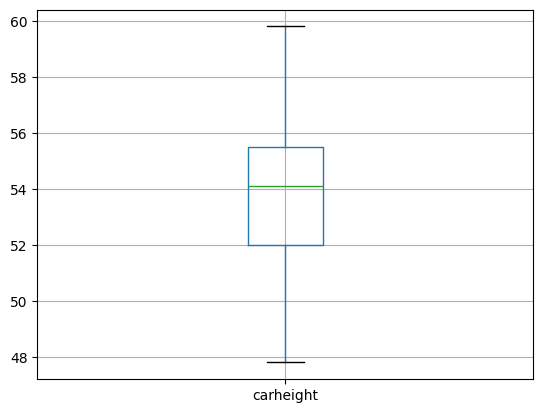

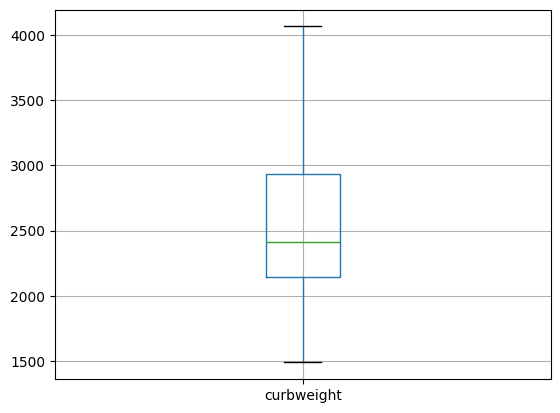

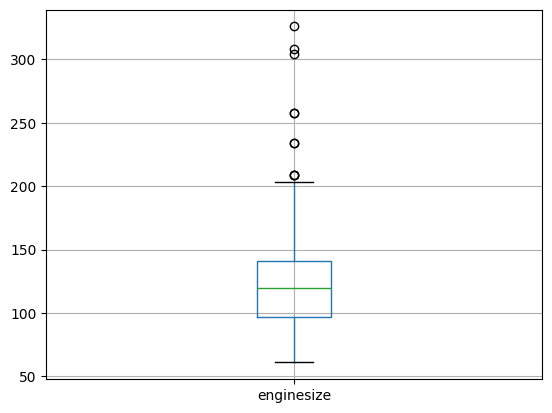

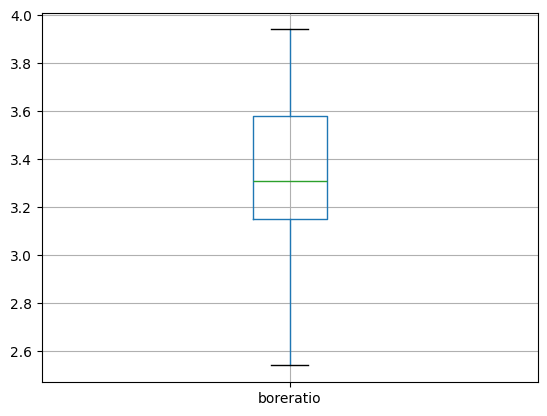

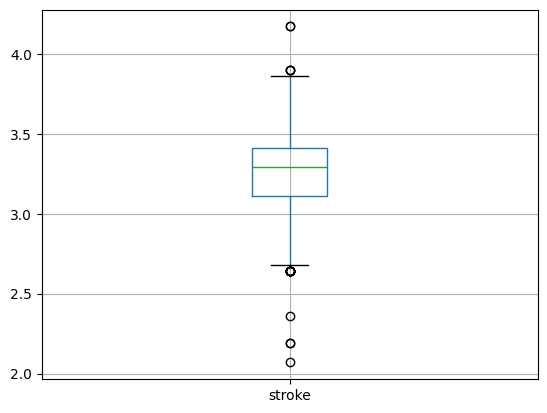

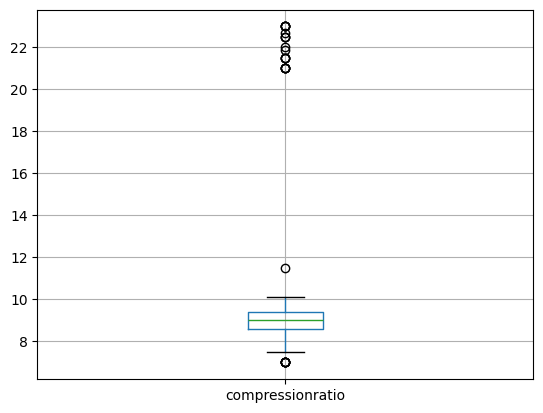

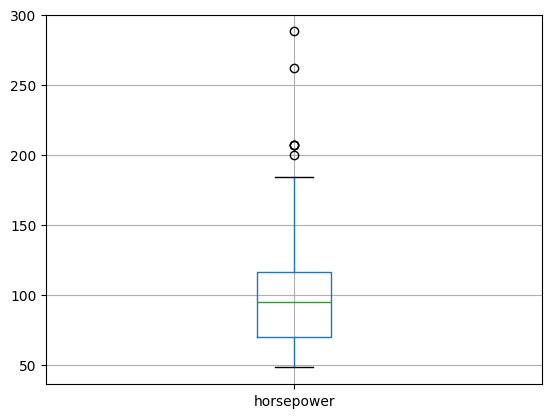

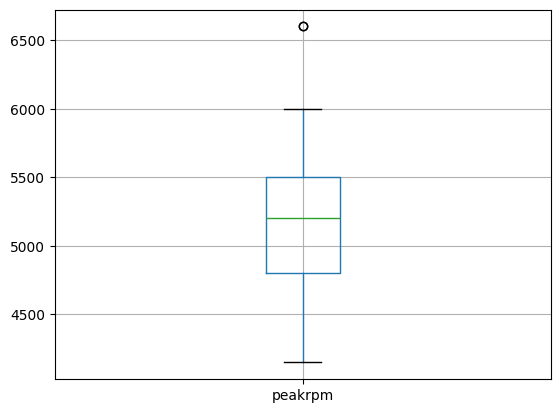

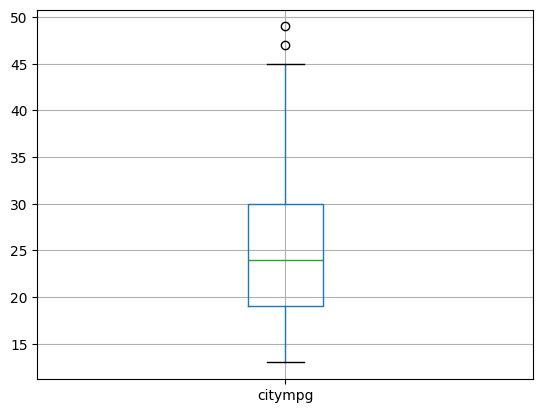

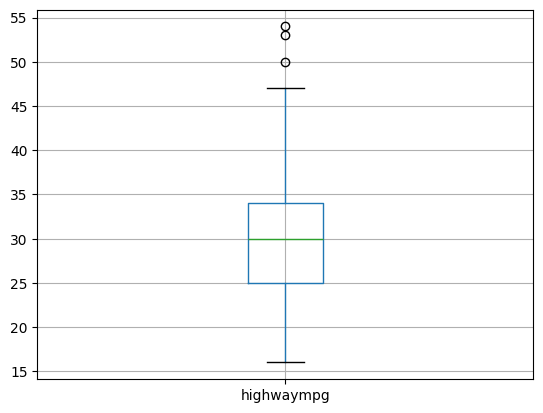

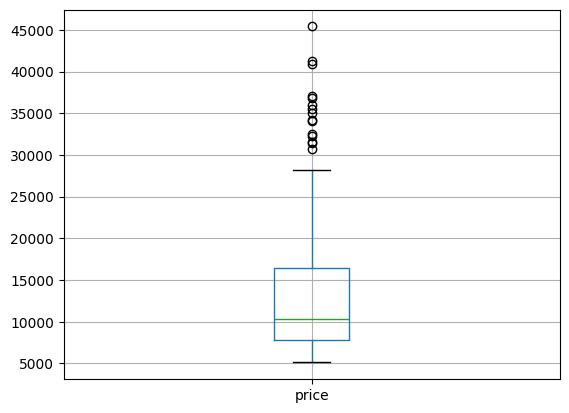

In [16]:
for x in file.select_dtypes(include ="number").columns:
  file[[x]].boxplot()
  plt.show()

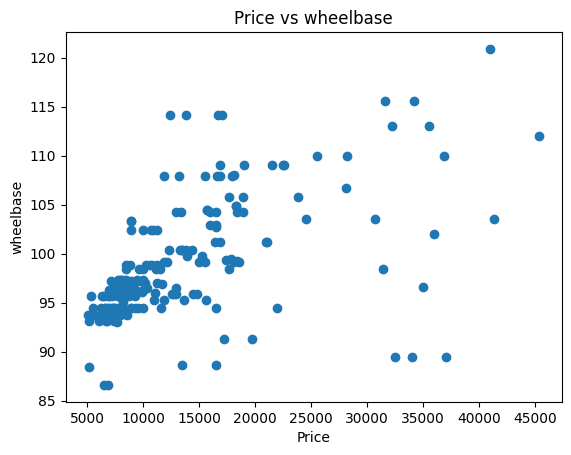

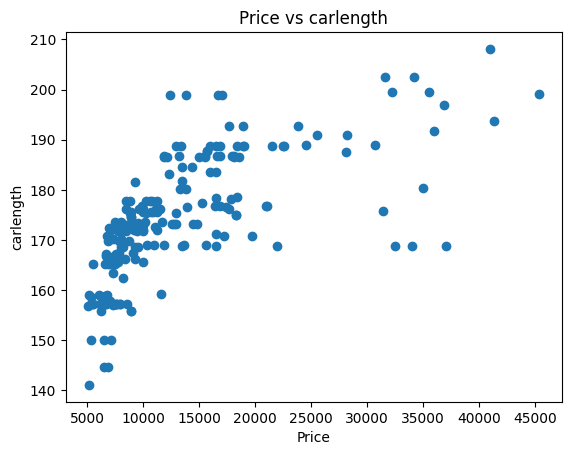

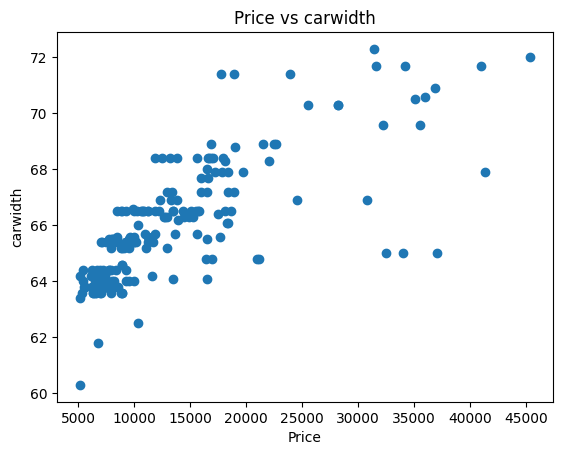

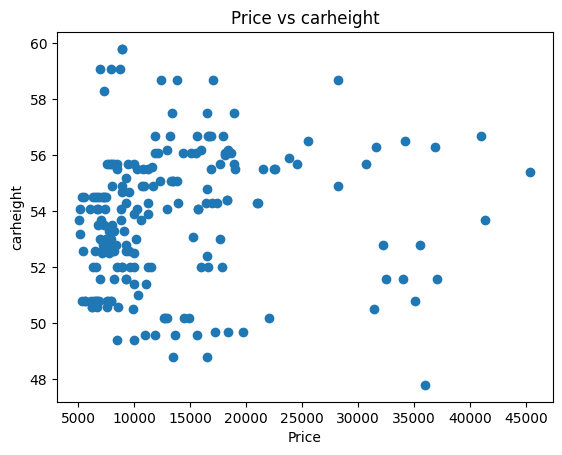

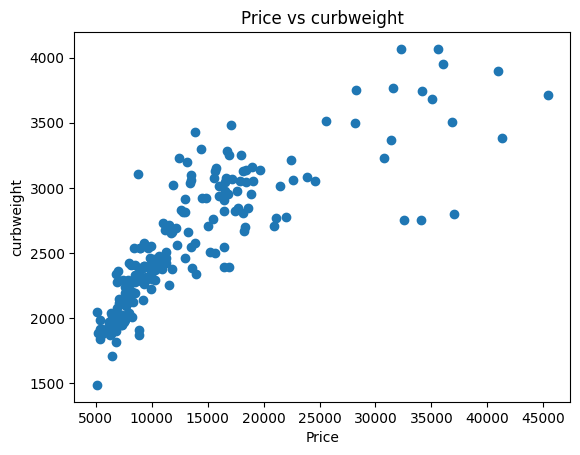

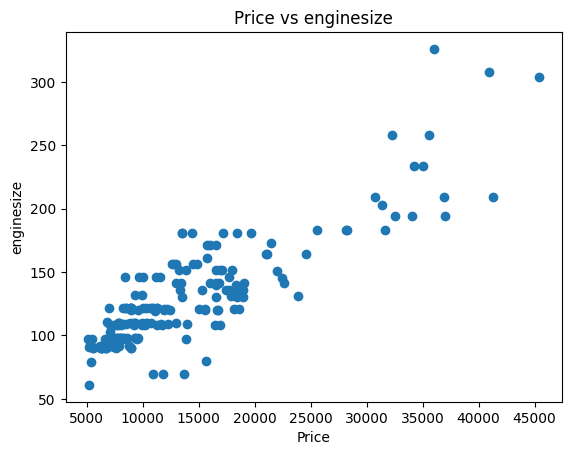

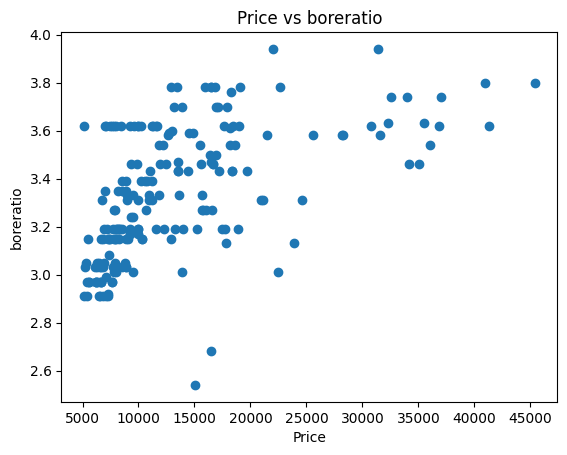

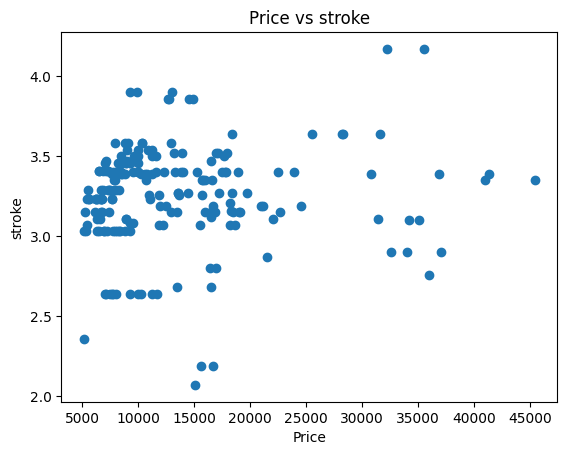

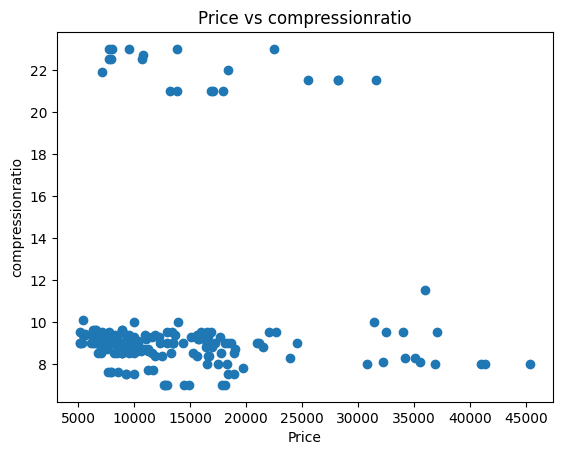

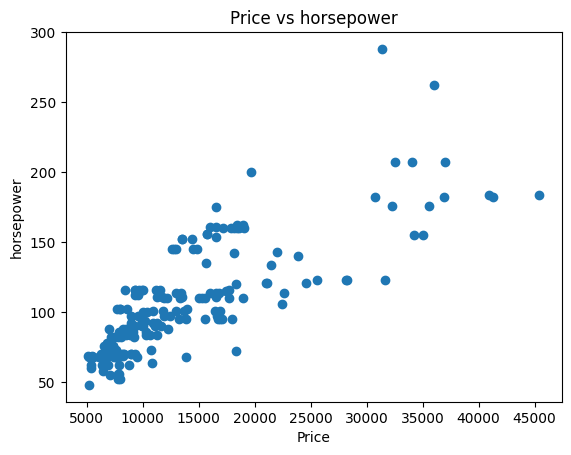

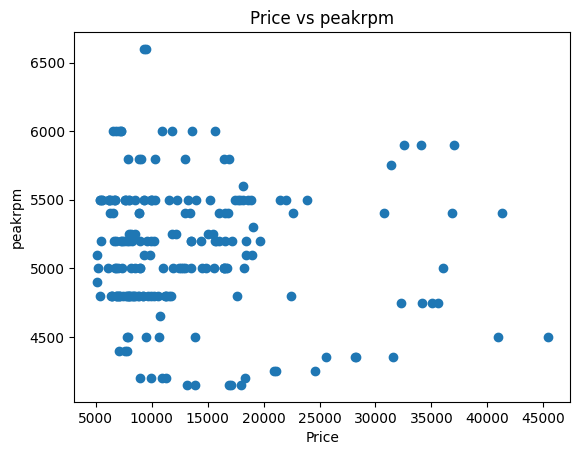

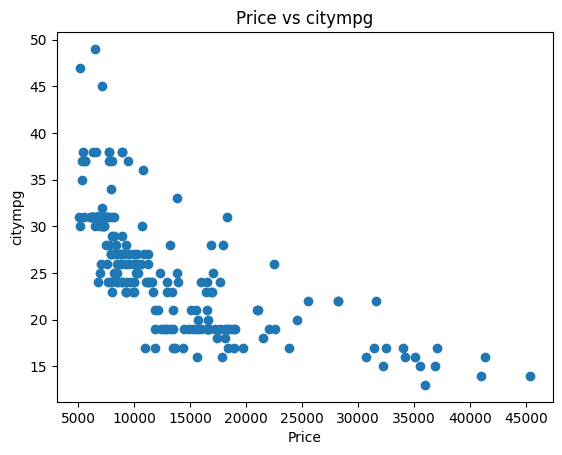

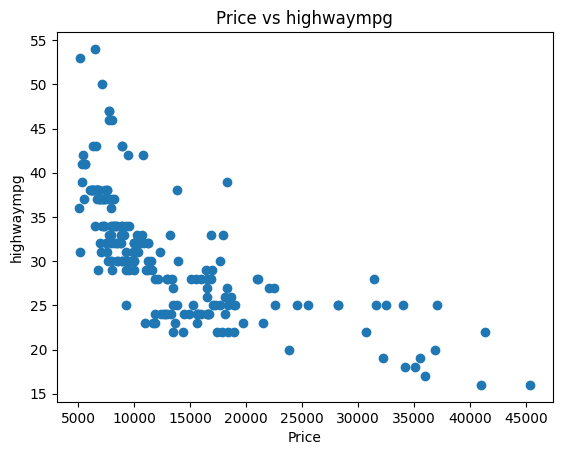

In [17]:
col  = ["wheelbase", "carlength", "carwidth", "carheight", "curbweight",
"enginesize", "boreratio", "stroke", "compressionratio", "horsepower", "peakrpm",
"citympg", "highwaympg"]
for x in col:
  plt.scatter(file["price"],file[x])
  plt.xlabel("Price")
  title = f'Price vs {x}'
  plt.title(title)
  plt.ylabel(x)
  plt.show()

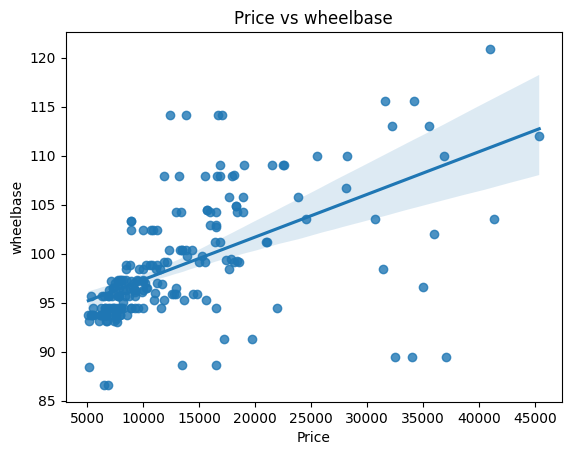

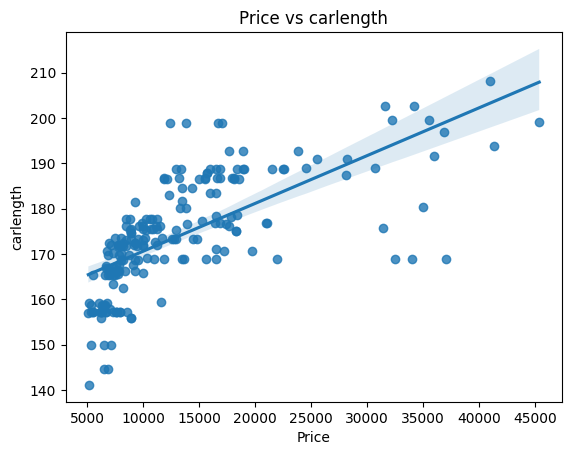

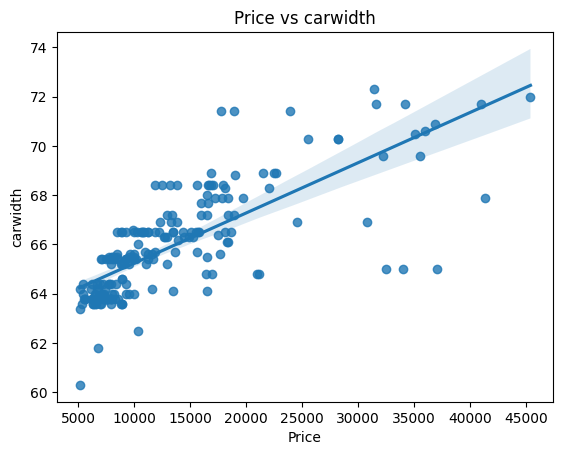

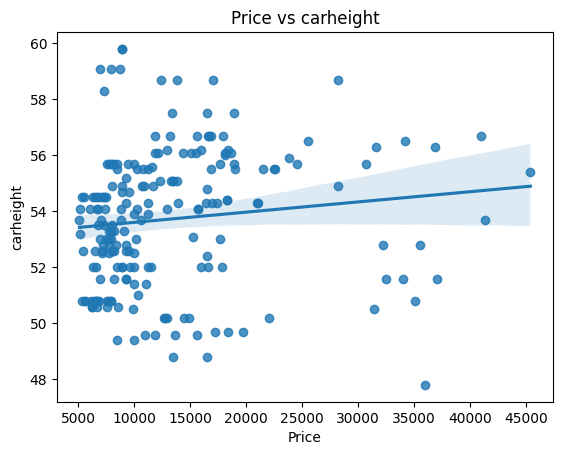

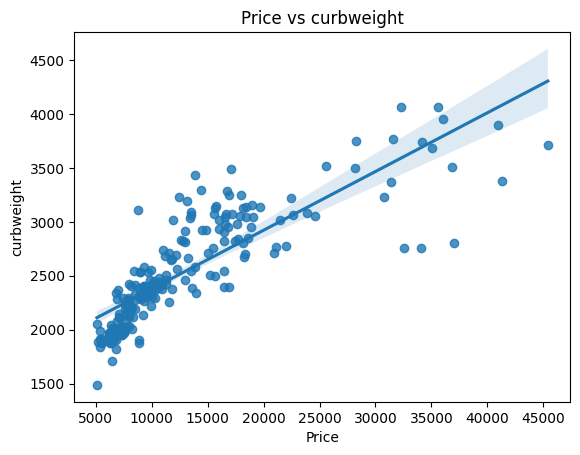

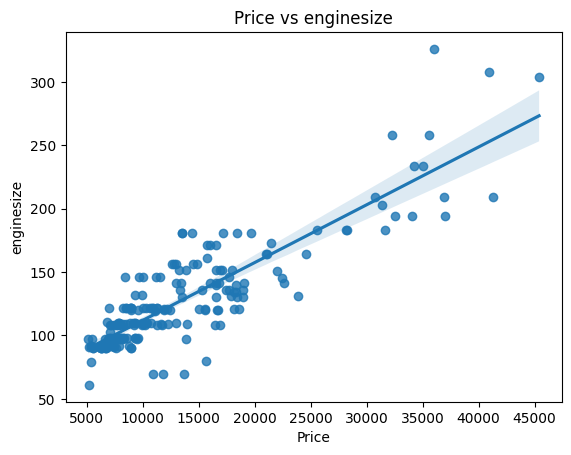

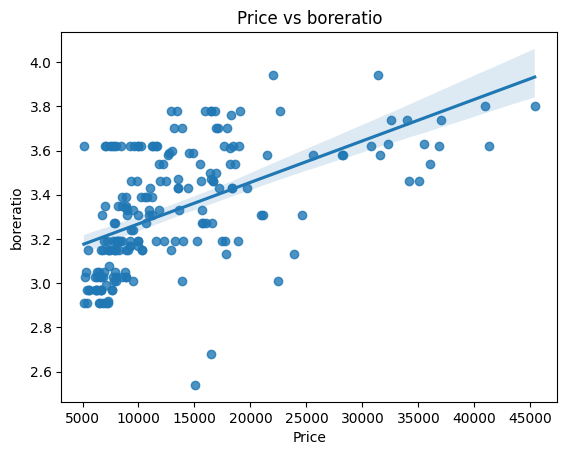

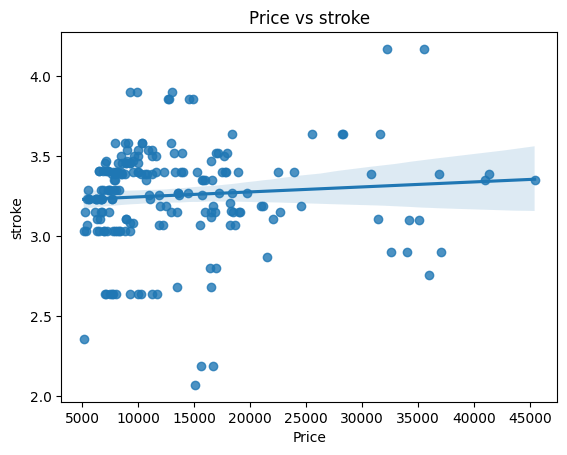

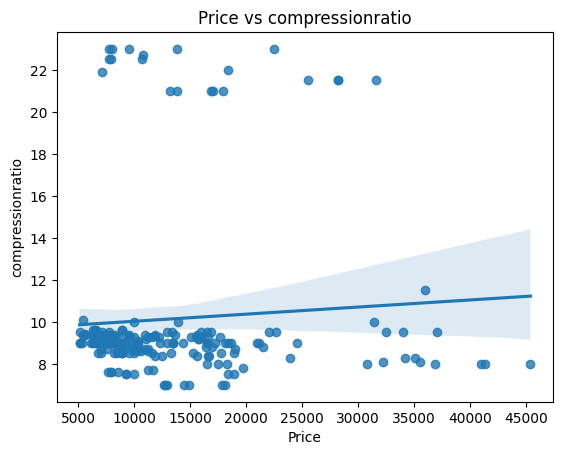

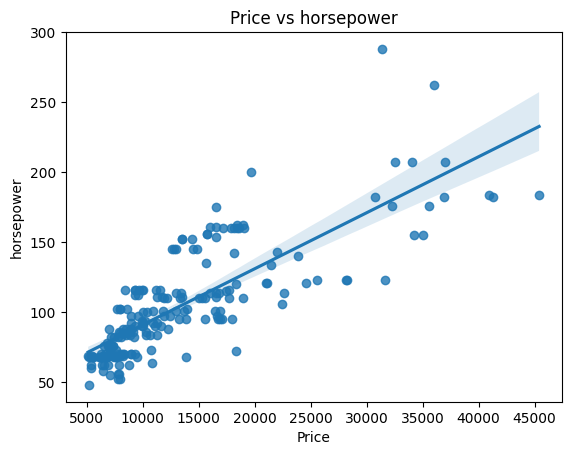

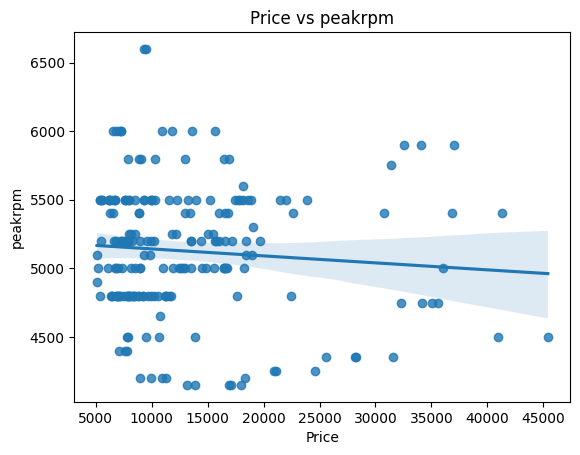

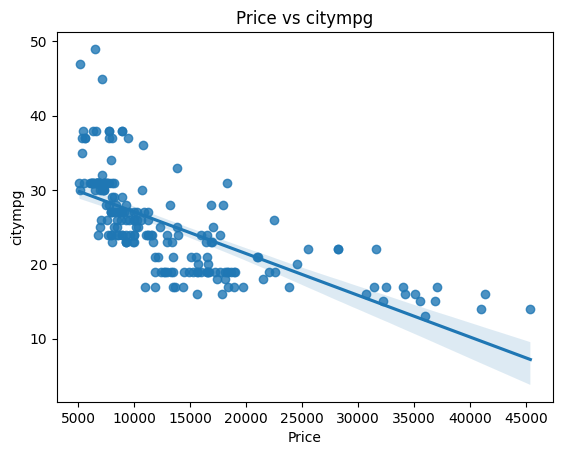

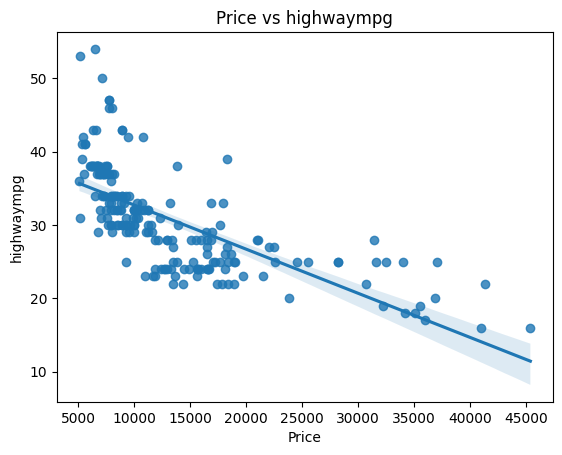

In [18]:
#  helps to visualize their linear relationships
col  = ["wheelbase", "carlength", "carwidth", "carheight", "curbweight",
"enginesize", "boreratio", "stroke", "compressionratio", "horsepower", "peakrpm",
"citympg", "highwaympg"]
for x in col:
  sns.regplot(x='price', y=x, data=file)
  plt.xlabel("Price")
  title = f'Price vs {x}'
  plt.title(title)
  plt.ylabel(x)
  plt.show()


In [19]:
lis_cat_col = ["fueltype", "aspiration", "doornumber", "carbody", "drivewheel", "enginelocation",
"enginetype", "cylindernumber", "fuelsystem", "symboling" ]

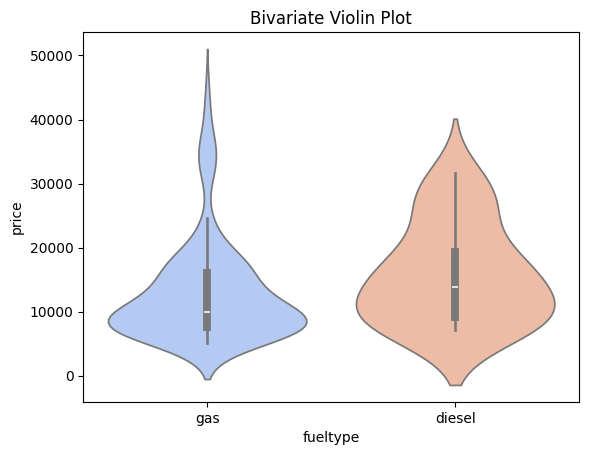

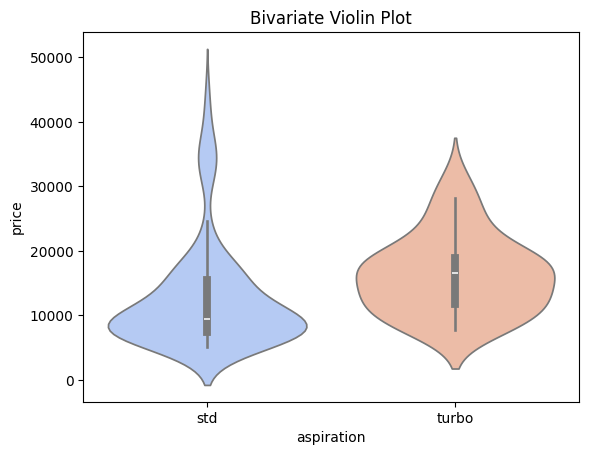

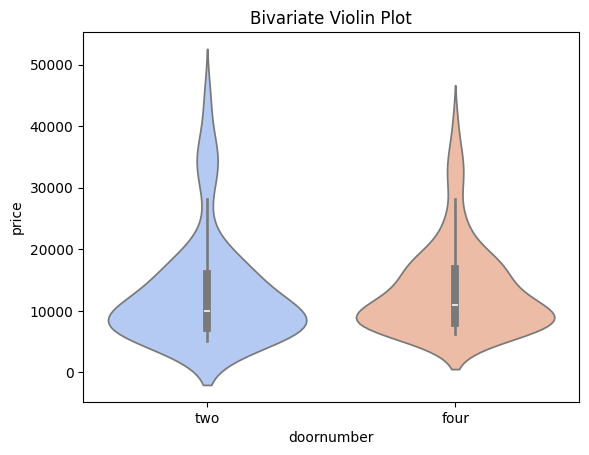

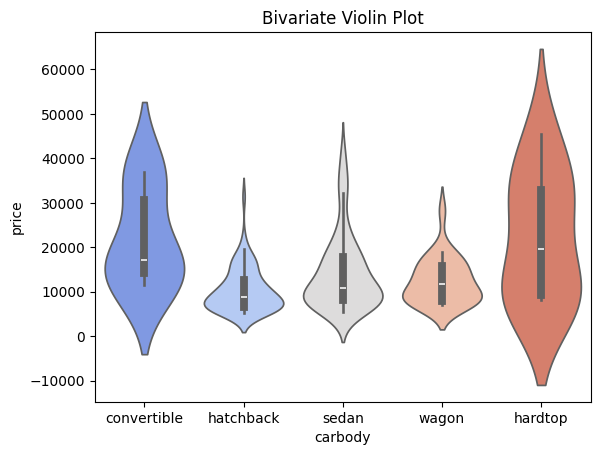

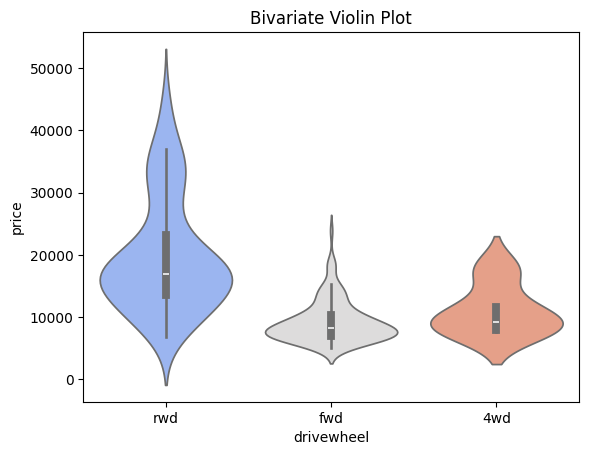

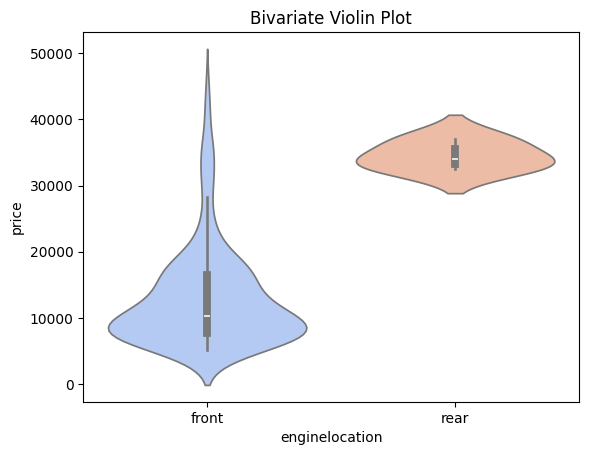

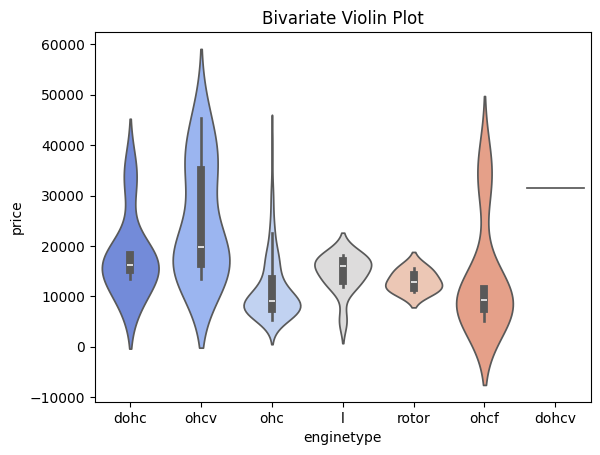

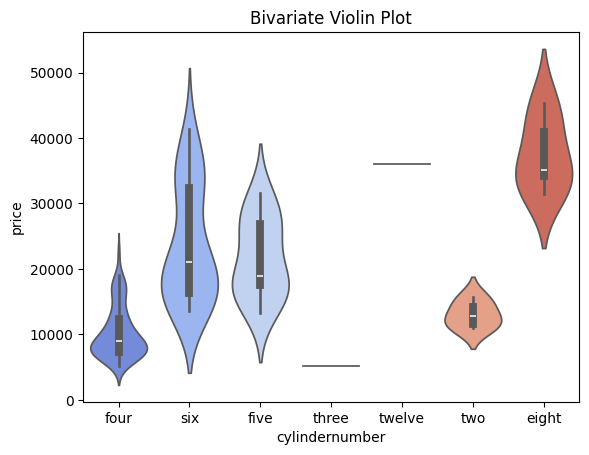

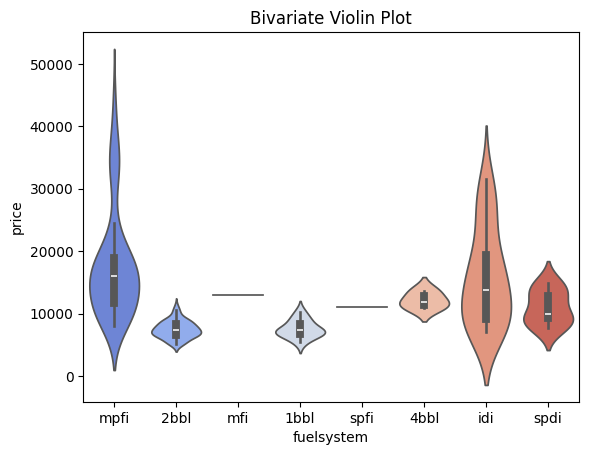

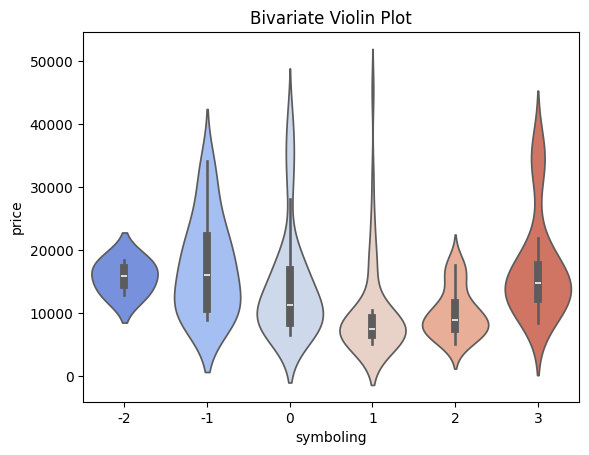

In [23]:
for x in lis_cat_col:
  sns.violinplot(x=x, y='price', data=file, palette='coolwarm')
  plt.title('Bivariate Violin Plot')
  plt.show()


🔹 **1. Correlation Analysis (Pearson)**  
**Why**: To detect linear relationships between independent variables and the target.  
**Use it to**: Remove irrelevant or redundant features early.


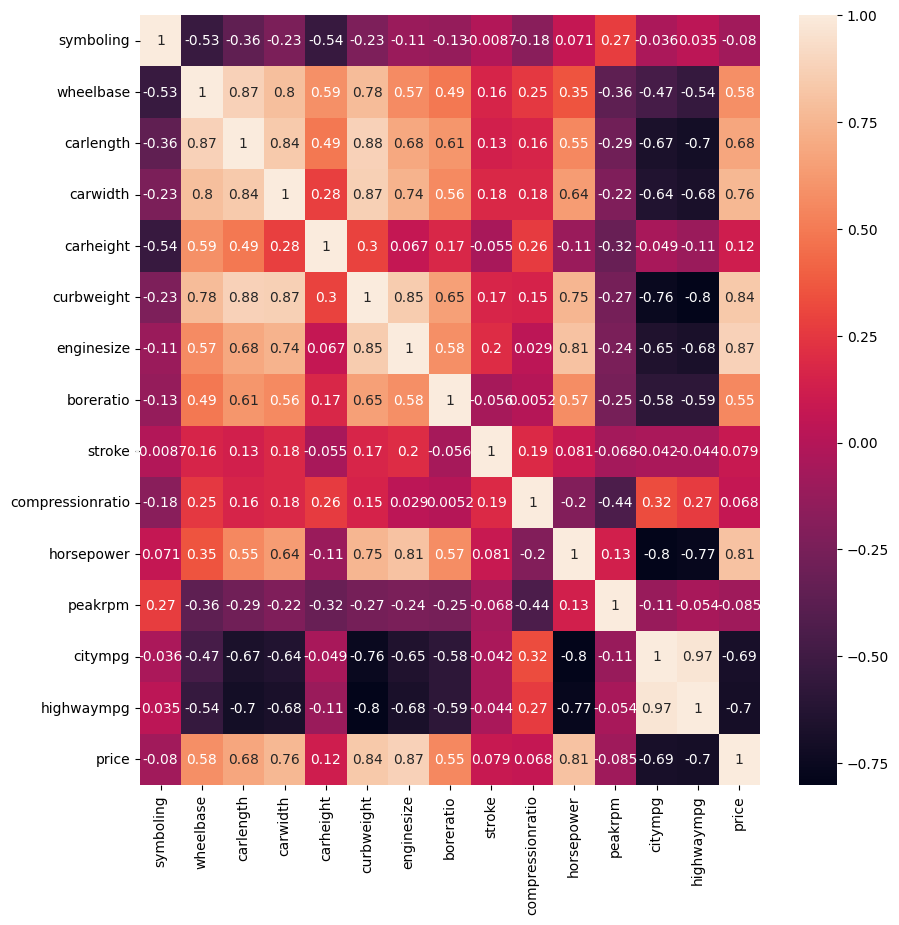

In [24]:
plt.figure(figsize=(10,10))
sns.heatmap(file.select_dtypes(include= "number").corr(), annot = True)
plt.show()

✍️ Summary
### ❌ Drop (Very Weak with price)
symboling, stroke, compressionratio, peakrpm

### ⚠️ Evaluate for Multicollinearity (choose only one from each group)
citympg vs highwaympg

curbweight vs enginesize vs carwidth vs carlength

### Keep (High impact on price)
enginesize, horsepower, curbweight, carwidth, wheelbase

Would you like a code example that automatically filters these based on correlation thresholds?

In [25]:
file = file.drop(["symboling", "stroke", "compressionratio", "peakrpm","carlength"], axis=1 )

## **2. Skewness**  
**Why**: Many regression models (especially linear ones) assume normally distributed features.  
**Use it to**: Apply log/sqrt transformations on skewed features.  
**Tool**: `df.skew()` in Pandas.

In [26]:
file.select_dtypes(include="number").skew()

,0
wheelbase,1.050214
carwidth,0.904003
carheight,0.063123
curbweight,0.681398
enginesize,1.947655
boreratio,0.020156
horsepower,1.405310
citympg,0.663704
highwaympg,0.539997
price,1.777678


### Transforming these due to high skew:

enginesize, compressionratio, horsepower, price

In [28]:
import numpy as np

# First, add a small constant to avoid log(0) issues
epsilon = 1e-5

# Log-transform the skewed features
file['enginesize_log'] = np.log(file['enginesize'] + epsilon)
# file['compressionratio_log'] = np.log(file['compressionratio'] + epsilon)
file['horsepower_log'] = np.log(file['horsepower'] + epsilon)
file['price_log'] = np.log(file['price'] + epsilon)


In [30]:
# file = file.drop(["enginesize", "compressionratio", "horsepower", "price"], axis =1)
file = file.drop(["enginesize",  "horsepower", "price"], axis =1)

file.select_dtypes(include="number").skew()


,0
wheelbase,1.050214
carwidth,0.904003
carheight,0.063123
curbweight,0.681398
boreratio,0.020156
citympg,0.663704
highwaympg,0.539997
enginesize_log,0.857828
horsepower_log,0.482838
price_log,0.672889


##  **3. P-Value (from Linear Regression Summary)**  
**Why**: Shows if a feature is statistically significant.  
**Use it to**: Drop features with p > 0.05 in OLS regression (e.g., using `statsmodels`).


In [31]:
import pandas as pd
import statsmodels.api as sm

# Separate target and features
y = file['price_log']
X = file.select_dtypes(include="number").drop('price_log', axis=1)

# Convert categorical features to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Add constant term for intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print summary to check p-values
print(model.summary())

# Extract features with p-value <= 0.05
p_values = model.pvalues
significant_features = p_values[p_values <= 0.05].index.tolist()

# Remove 'const' if present
if 'const' in significant_features:
    significant_features.remove('const')

# Final DataFrame with significant features only
X_significant = X[significant_features]


                            OLS Regression Results                            
Dep. Variable:              price_log   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     132.6
Date:                Mon, 12 May 2025   Prob (F-statistic):           3.74e-78
Time:                        18:53:36   Log-Likelihood:                 51.390
No. Observations:                 205   AIC:                            -82.78
Df Residuals:                     195   BIC:                            -49.55
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.6621      1.001      2.

## **4. Variance Inflation Factor (VIF)**  
**Why**: Detects multicollinearity (when features are too correlated with each other).  
**Use it to**: Drop or combine highly collinear features.  
**Threshold**: VIF > 5 or 10 is usually problematic.

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# Select only numeric features (excluding target variable)
X = file.select_dtypes(include="number").drop(columns='price_log')  # drop actual target columns if present
X = add_constant(X)  # adds intercept term

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


           Feature          VIF
0            const  5508.928274
1        wheelbase     5.605030
2         carwidth     5.222986
3        carheight     1.983991
4       curbweight    11.776095
5        boreratio     1.884053
6          citympg          inf
7       highwaympg          inf
8   enginesize_log     6.056811
9   horsepower_log     8.126045
10         avg_mpg          inf


citympg vs highwaympg:
These two are highly correlated. Consider:

In [36]:
file.drop("enginesize_log",axis=1)
file['avg_mpg'] = (file['citympg'] + file['highwaympg']) / 2


In [37]:
file.columns

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carwidth', 'carheight',
       'curbweight', 'enginetype', 'cylindernumber', 'fuelsystem', 'boreratio',
       'citympg', 'highwaympg', 'enginesize_log', 'horsepower_log',
       'price_log', 'avg_mpg'],
      dtype='object')

## 5. Outliers
### Isolation Forest (for high-dimensional outliers)

In [38]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)  # 5% assumed outliers
outlier_pred = iso.fit_predict( file.select_dtypes(include="number").select_dtypes(include=['float64', 'int64']))
file['outlier'] = outlier_pred  # -1 is outlier, 1 is normal

# Filter only outliers
df_outliers = file[file['outlier'] == -1]
df_outliers['outlier'].value_counts()

,count
outlier,
-1,11


In [39]:
df_outliers

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carwidth,carheight,...,cylindernumber,fuelsystem,boreratio,citympg,highwaympg,enginesize_log,horsepower_log,price_log,avg_mpg,outlier
18,chevrolet impala,gas,std,two,hatchback,fwd,front,88.4,60.3,53.2,...,three,2bbl,2.91,47,53,4.110874,3.871201,8.546946,50.0,-1
30,honda civic,gas,std,two,hatchback,fwd,front,86.6,63.9,50.8,...,four,1bbl,2.91,49,54,4.521789,4.060443,8.776321,51.5,-1
47,jaguar xj,gas,std,four,sedan,rwd,front,113.0,69.6,52.8,...,six,mpfi,3.63,15,19,5.552960,5.170484,10.381273,17.0,-1
48,jaguar xf,gas,std,four,sedan,rwd,front,113.0,69.6,52.8,...,six,mpfi,3.63,15,19,5.552960,5.170484,10.478695,17.0,-1
49,jaguar xk,gas,std,two,sedan,rwd,front,102.0,70.6,47.8,...,twelve,mpfi,3.54,13,17,5.786897,5.568345,10.491274,15.0,-1
71,buick opel isuzu deluxe,gas,std,four,sedan,rwd,front,115.6,71.7,56.5,...,eight,mpfi,3.46,16,18,5.455321,5.043425,10.439513,17.0,-1
72,buick skylark,gas,std,two,convertible,rwd,front,96.6,70.5,50.8,...,eight,mpfi,3.46,16,18,5.455321,5.043425,10.464702,17.0,-1
73,buick century special,gas,std,four,sedan,rwd,front,120.9,71.7,56.7,...,eight,mpfi,3.80,14,16,5.730100,5.214936,10.620351,15.0,-1
74,buick regal sport coupe (turbo),gas,std,two,hardtop,rwd,front,112.0,72.0,55.4,...,eight,mpfi,3.80,14,16,5.717028,5.214936,10.723267,15.0,-1
90,nissan gt-r,diesel,std,two,sedan,fwd,front,94.5,63.8,54.5,...,four,idi,2.99,45,50,4.634729,4.007333,8.867709,47.5,-1


# Model building

In [40]:

# ---------------------------
# 1. Define features and target
# ---------------------------


X = file.drop("price_log", axis =1)
y = file["price_log"]

# ---------------------------
# 2. Identify categorical and numerical columns
# ---------------------------
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ---------------------------
# 3. Preprocessing pipelines
# ---------------------------
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# ---------------------------
# 4. Train-test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------
# 5. Build pipeline and model
# ---------------------------
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# ---------------------------
# 6. Train model
# ---------------------------
model.fit(X_train, y_train)

# ---------------------------
# 7. Evaluate model
# ---------------------------
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.2f}")
print(f"Test R² Score: {r2:.2f}")


Test MSE: 0.02
Test R² Score: 0.94
